<a href="https://colab.research.google.com/github/JustinMann123/EMSC2010_Week7_SeismicBabes/blob/main/FINAL_EMSC2010_Group_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project 2: Seismic Babes

## 1. Project Overview
Group name: Seismic Babes

Project week: 7-8

Project title: Solar Radiation Analysis via Probabilistic Programming

Datasets used (name and source): Solar Radiation, NASA Prediction Of Worldwide Energy Resources https://power.larc.nasa.gov/data-access-viewer/

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Owen | Eloise | Yes| Add note|
| Data steward | Eloise | Justin | Yes| Add note|
| Analysis / modelling | Justin | Clover | Yes| Add note|
| Visualisation / interpretation | Clover | Freddie | Yes| Add note|
| Narrative | Freddie | Ed | Yes| Add note|
| Quality Control / Reproducibility  | Ed | Owen | Yes| Add note|


# Question

Will two cities at the same latitude (Sydney and Buenos Aires) receive similar solar radiation?

# Hypothesis and Justification

We hypothesise that two cities at similar latitudes should receive comparable solar radiation.

The selected cities Buenos Aires (Appoximately, 34.6037° S, 58.3821° W) and Sydney (Approximately, 33.8623° S, 151.2077° E) were chosen as they share similar latitudes and both have a humid subtropical climate, reducing cloud cover and sun exposure as a confounding variable.

However rates of population growth, natural differences in atmospheric conditions due to ocean currents and other factors may have impacts on solar radiation. This should be taken into consideration when a comparison between the two is made.

##FAIR DATA SECTION

**Findability (F):**

The international sunspot number dataset is published and maintained by the Solar
Influences Data Analysis Center (SILSO) at the Royal Observatory of Belgium. The
dataset is freely accessible online at https://www.sidc.be/SILSO/datafiles

**Accessibility (A):**

The data is openly available for download  directly from the SILSO website
without requiring an account or login. It is provided in plain text CSV format. I have attached the url to the data file used in this analysis.

See attahced data file in GitHub (URL)!!

**Interoperability (I):**

The dataset is provided in a plain text CSV format using semicolon delimiters, which
can be opened by most imports such as numpy or pandas. The csv file containes both year/month columns and as a decimal year value. Additoanly the observtions has corresponidign standard diviation and additonatl meta data.


**Reusability (R):**

The dataset is published under a Creative Commons licence, meaning it
can be freely shared and reused for non-commercial purposes (including education)

provided appropriate credit is given. The recommended citation is:

The Royal Observatory of Belgium undertakes to make this site accessible, in accordance with the following legislation: Law of 19 July 2018 relating to the accessibility of websites and mobile applications of public sector bodies .

This accessibility statement applies to the website  https://www.astro.oma.be


please see terms of use within SILSO

(https://www.astro.oma.be/en/information/terms-use/)

# Data Import - Ellie

I used the following website to get data for the All Sky Surface Shortwave Downward Irradiance Values in both Sydney and Buenos Aires over the past 36 months (3 years):

https://power.larc.nasa.gov/data-access-viewer/

I placed data found into a table in google sheets then dowloaded it to microsoft excel (.xlsx) and attatched this as file.

I further printed this file into the code below:

(Note: An issue discovered was that some data points were by cloud cover on the day they were observed, however each monthly solar radiation value is the mean solar radiation across all days that month, meaning uncertainty is limited)

In [ ]:
import pandas as pd

url = 'https://github.com/JustinMann123/EMSC2010_Week7_SeismicBabes/raw/main/Solar_Radiation_Data%20(2).xlsx'

df_S = pd.read_excel(url, sheet_name='S')
df_BA = pd.read_excel(url, sheet_name='BA')

print(df_S.to_string(index=False))
print(df_BA.to_string(index=False))

Date (YYYY-MM)  Period (Months)  Solar Radiation Level (W/m^2)
    2022-01-01                1                         6.3022
    2022-02-01                2                         5.3952
    2022-03-01                3                         3.9101
    2022-04-01                4                         3.5352
    2022-05-01                5                         2.7722
    2022-06-01                6                         2.7252
    2022-07-01                7                         2.4295
    2022-08-01                8                         3.3895
    2022-09-01                9                         4.1635
    2022-10-01               10                         4.7155
    2022-11-01               11                         7.3793
    2022-12-01               12                         7.0848
    2023-01-01               13                         6.4375
    2023-02-01               14                         6.5794
    2023-03-01               15                        

**Redundancy manual data file input**

Please only use one method. Data file loacted in GitHub repository

In [ ]:
# import pandas as pd

# spreadsheet_name = "Solar_Radiation_Data.xlsx"
# worksheet_S = 'S' # The sheet name containing Sydney Solar radiation data
# worksheet_BA = 'BA' # The sheet name containing Buenos Aires solar radiation data

# df_S = pd.read_excel(spreadsheet_name, sheet_name=worksheet_S) #read the Sydney data into a dataframe
# df_BA = pd.read_excel(spreadsheet_name, sheet_name=worksheet_BA) #read the Buenos Aires data into a dataframe

# print(df_S.to_string(index=False)) #show the dataframe table for Sydney, removing the row numbers
# print(df_BA.to_string(index=False))

# Analysis / Modelling - Justin

In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

For this experiment we will run both a non-informative and informative, noting this could indicate the effectivness of the data and priors.

Checking data frames to ensure normal distribution:

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

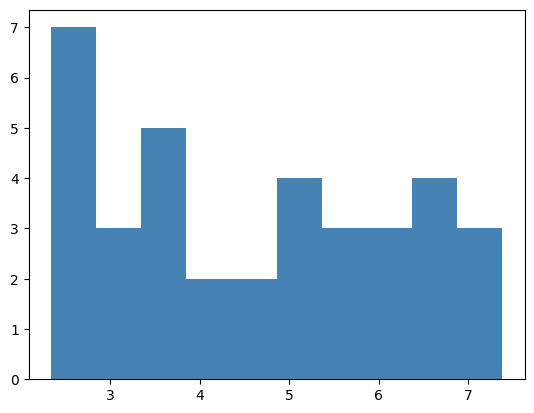

In [ ]:
plt.hist(df_S["Solar Radiation Level (W/m^2)"], bins=10, label='Sydney', color='steelblue')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

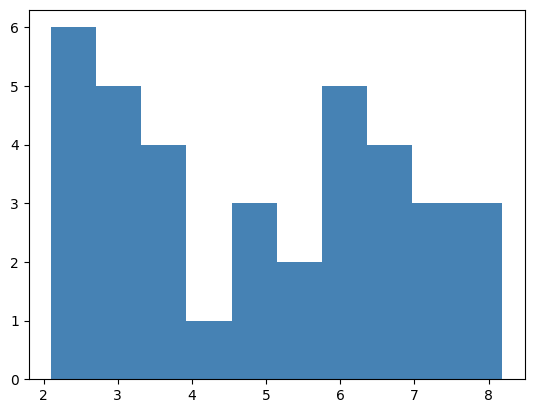

In [ ]:
plt.hist(df_BA["Solar Radiation Level (W/m^2)"], bins=10, label='Sydney', color='steelblue')
plt

The distributions show some deviation from normality, likely due to seasonal differences and the short temporal range of the data. A normal distribution is assumed for the purposes of this analysis

<Axes: title={'center': 'mu_uninformed_BA'}>

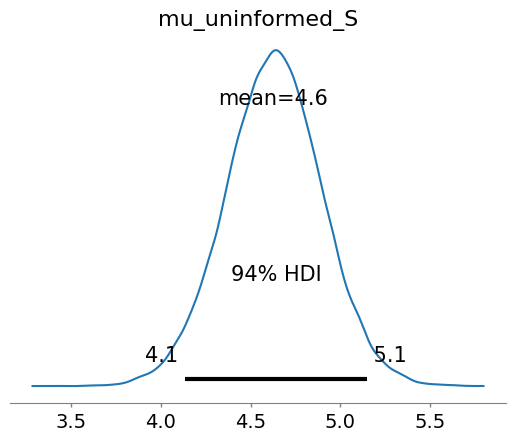

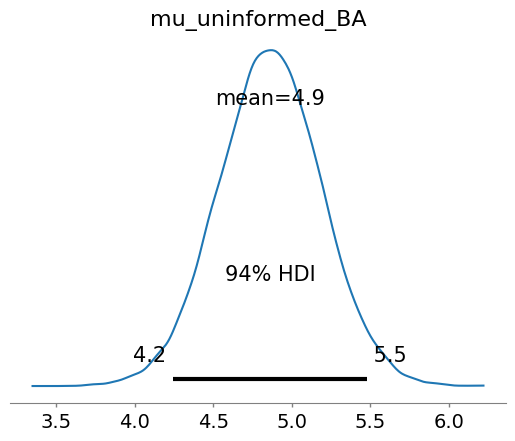

In [ ]:
## non informative - code adpated from EMSC2010_W7_L1_NB3

with pm.Model() as informative_model:

  # Sydney parameters
  mu_uninformed_S = pm.Flat("mu_uninformed_S")                          # flat prior on μ
  log_sigma_uninformed_S = pm.Flat("log_sigma_uninformed_S")            # flat prior on log(σ)
  sigma_uninformed_S = pm.Deterministic("sigma_uninformed_S", pm.math.exp(log_sigma_uninformed_S)) #represents the non-informative prior
  obs_uninformed_S = pm.Normal("obs_uninformed_S", mu=mu_uninformed_S, sigma=sigma_uninformed_S, observed=df_S["Solar Radiation Level (W/m^2)"])

  # Buenos Aires parameters
  mu_uninformed_BA = pm.Flat("mu_uninformed_BA")                          # flat prior on μ
  log_sigma_uninformed_BA = pm.Flat("log_sigma_uninformed_BA")            # flat prior on log(σ) - Corrected variable name string
  sigma_uninformed_BA = pm.Deterministic("sigma_uninformed_BA", pm.math.exp(log_sigma_uninformed_BA)) #represents the non-informative prior
  obs_uninformed_BA = pm.Normal("obs_uninformed_BA", mu=mu_uninformed_BA, sigma=sigma_uninformed_BA, observed=df_BA["Solar Radiation Level (W/m^2)"])

  # Obtain 20,000 samples from the posterior
  trace_uninformed = pm.sample(20000, tune=2000, return_inferencedata=True, progressbar=False)

# Plot the posterior distributions
az.plot_posterior(trace_uninformed, var_names=["mu_uninformed_S"])
az.plot_posterior(trace_uninformed, var_names=["mu_uninformed_BA"])

## Justin code

## Justification for Informed Prior

Both sites reside within the same latitude band, with Sydney's latitude at -33.8688° and Buenos Aires at -34.6076°.

According to NASA (https://science.nasa.gov/earth/earth-observatory/climate-and-earths-energy-budget/), the solar radiation received at Earth's surface varies by time and latitude. The tropics (from 0 to 23.5° latitude) receive about 90% of the energy compared to the equator, the mid-latitudes (45°) roughly 70%, and the Arctic and Antarctic Circles about 40%.

With Sydney and Buenos Aires both residing at approximately 34° south of the equator, we therefore expect roughly 80% of equatorial surface radiation. Equatorial regions (0-10°) receive 1,800-2,800 kWh/m²/year with minimal seasonal variation, which converts to (1,800-2,800 kWh/m²/year ÷ 365) = 4.9-7.67 kWh/m²/day. A mean of approximately 6.3 kWh/m²/day is therefore assumed for average equatorial solar radiation. Note that this figure is drawn from a non-peer-reviewed source (https://solartechonline.com/blog/what-is-solar-irradiation-complete-guide/).

Applying the NASA latitude scaling factor to estimate the prior value at 34° south: 6.3 kWh/m²/day x 0.80 = 5.0 kWh/m²/day. A conservative standard deviation of 1.5 kWh/m²/day is adopted to reflect uncertainty in both the equatorial baseline and the latitude scaling approximation.


<Axes: title={'center': 'mu_inform_S'}>

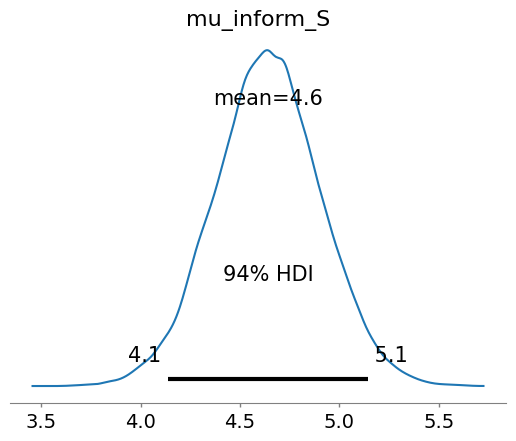

In [ ]:
## Informative model SYD

with pm.Model() as informed_S_model:

    # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
    mu_inform_S = pm.Normal("mu_inform_S", mu=5, sigma=1.5)

    # Prior for std of solar radiation — HalfNormal with a standard deviation of 20.
    sigma_inform_S = pm.HalfNormal("sigma_inform_S", sigma=2)

    # Likelihood given the data
    obs_S = pm.Normal("obs_S", mu=mu_inform_S, sigma=sigma_inform_S, observed=df_S["Solar Radiation Level (W/m^2)"])

    # Obtain 20,000 samples from the posterior
    trace_informed_S = pm.sample(20000, tune=2000, return_inferencedata=True,progressbar=False)

#plot the posterior distribution for the mean
az.plot_posterior(trace_informed_S, var_names=["mu_inform_S"])

## using same PRIOR - SIGMA -

<Axes: title={'center': 'mu_inform_BA'}>

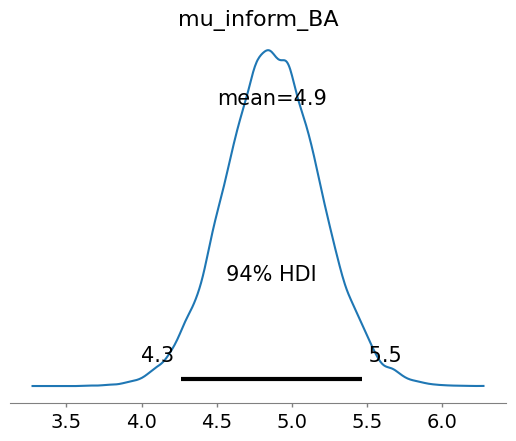

In [ ]:
with pm.Model() as informed_BA_model:

    # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
    mu_inform_BA = pm.Normal("mu_inform_BA", mu=5, sigma=1.5)

    # Prior for std of heights — HalfNormal with a standard deviation of 20.
    sigma_inform_BA = pm.HalfNormal("sigma_inform_BA", sigma=2)

    # Likelihood given the data
    obs_BA = pm.Normal("obs", mu=mu_inform_BA, sigma=sigma_inform_BA, observed=df_BA["Solar Radiation Level (W/m^2)"])

    # Obtain 20,000 samples from the posterior
    trace_informed_BA = pm.sample(20000, tune=2000, return_inferencedata=True, progressbar=False)

#plot the posterior distribution for the mean
az.plot_posterior(trace_informed_BA, var_names=["mu_inform_BA"])

In [ ]:
##extracting the posterior samples for un-informed  sampes as a numpy array

mu_samples_uninformed_S = trace_uninformed.posterior['mu_uninformed_S'].values.flatten()
mu_samples_uninformed_BA = trace_uninformed.posterior['mu_uninformed_BA'].values.flatten()

##extracting the posterior samples for informed  sampes as a numpy array

mu_samples_informed_S = trace_informed_S.posterior['mu_inform_S'].values.flatten()
mu_samples_informed_BA = trace_informed_BA.posterior['mu_inform_BA'].values.flatten()

In [ ]:
### comparing means of un-informed sample
mu_diff_uninformed= mu_samples_uninformed_S - mu_samples_uninformed_BA

### comparing means of un-informed sample
mu_diff_informed= mu_samples_informed_S - mu_samples_informed_BA

In [ ]:
### Find if zero is within the 95% highest density interval (un-informed)
az.hdi(mu_diff_uninformed, hdi_prob=0.95)

array([-1.0528081 ,  0.60447346])

In [ ]:
### Find if zero is within the 95% highest density interval (informed)
az.hdi(mu_diff_informed, hdi_prob=0.95)

array([-1.04086473,  0.59153863])

# Visualisation

# **FIGURE 1**

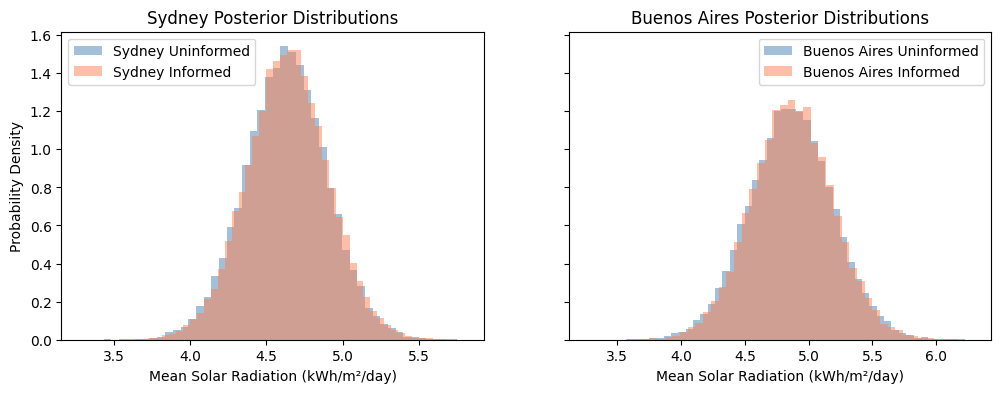

In [ ]:
## Overlapping Posterior Distributions (to compare informed/uninformed)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Sydney plot
axes[0].hist(mu_samples_uninformed_S, bins=50, density=True, alpha=0.5, label='Sydney Uninformed', color='steelblue')
axes[0].hist(mu_samples_informed_S, bins=50, density=True, alpha=0.5, label='Sydney Informed', color='coral')
axes[0].set_title('Sydney Posterior Distributions')
axes[0].set_xlabel('Mean Solar Radiation (kWh/m²/day)')
axes[0].set_ylabel('Probability Density')
axes[0].legend()

# Buenos Aires plot
axes[1].hist(mu_samples_uninformed_BA, bins=50, density=True, alpha=0.5, label='Buenos Aires Uninformed', color='steelblue')
axes[1].hist(mu_samples_informed_BA, bins=50, density=True, alpha=0.5, label='Buenos Aires Informed', color='coral')
axes[1].set_title('Buenos Aires Posterior Distributions')
axes[1].set_xlabel('Mean Solar Radiation (kWh/m²/day)')
axes[1].legend()
plt.show()

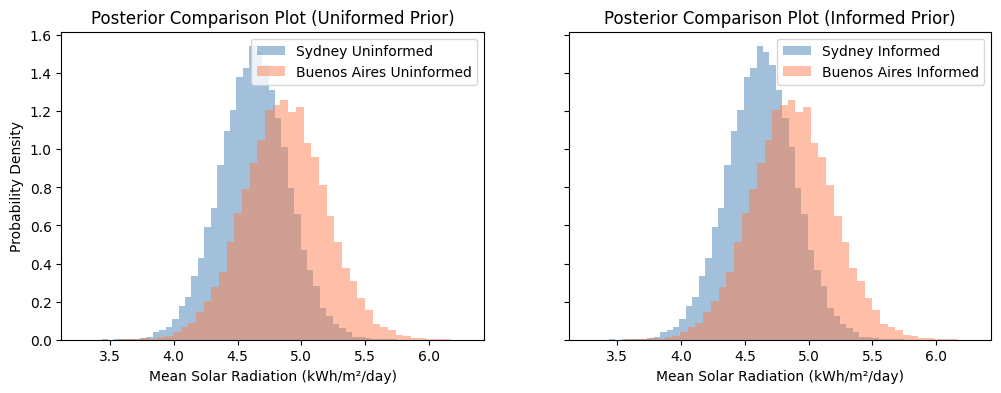

In [ ]:
## Overlapping Posterior Distributions (to compare informed/uninformed)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Sydney plot
axes[0].hist(mu_samples_uninformed_S, bins=50, density=True, alpha=0.5, label='Sydney Uninformed', color='steelblue')
axes[0].hist(mu_samples_informed_BA, bins=50, density=True, alpha=0.5, label='Buenos Aires Uninformed', color='coral')
axes[0].set_title('Posterior Comparison Plot (Uniformed Prior)')
axes[0].set_xlabel('Mean Solar Radiation (kWh/m²/day)')
axes[0].set_ylabel('Probability Density')
axes[0].legend()

# Buenos Aires plot
axes[1].hist(mu_samples_uninformed_S, bins=50, density=True, alpha=0.5, label='Sydney Informed', color='steelblue')
axes[1].hist(mu_samples_informed_BA, bins=50, density=True, alpha=0.5, label='Buenos Aires Informed', color='coral')
axes[1].set_title('Posterior Comparison Plot (Informed Prior)')
axes[1].set_xlabel('Mean Solar Radiation (kWh/m²/day)')
axes[1].legend()
plt.show()

## **FIGURE 2**

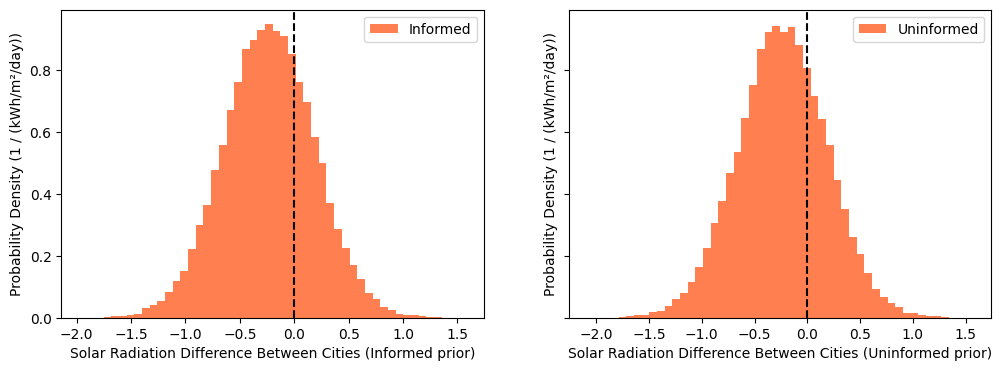

FIGURE 3


In [ ]:
## Plotting the posterior mean differences for each model
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(mu_diff_informed, bins=50, label='Informed', color='coral',density=True)
axes[0].set_xlabel('Solar Radiation Difference Between Cities (Informed prior)')
axes[0].set_ylabel('Probability Density (1 / (kWh/m²/day))')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].legend()





axes[1].hist(mu_diff_uninformed, bins=50, label='Uninformed', color='coral',density=True)
axes[1].set_xlabel('Solar Radiation Difference Between Cities (Uninformed prior)')
axes[1].set_ylabel('Probability Density (1 / (kWh/m²/day))')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].legend()
plt.show()

print('FIGURE 3')

## **FIGURE 3**

# **What impact did the Informed vs uninformed priors on the models**

**Quantitative representation of how much the informative priors influenced the posterior distributions of mean solar radiation**

In [ ]:
# posterior distributions of the differences between the non-informative and informative priors
#impact of the prior on Sydney
sydney_prior_impact = mu_samples_informed_S - mu_samples_uninformed_S
### Find if zero is within the 95% highest density interval (un-informed)


# impact of the prior on Buenos Aires
ba_prior_impact = mu_samples_informed_BA - mu_samples_uninformed_BA


In [ ]:
az.hdi(sydney_prior_impact, hdi_prob=0.95)

array([-0.74935612,  0.73917813])

In [ ]:
az.hdi(ba_prior_impact, hdi_prob=0.95)

array([-0.85864044,  0.95530127])

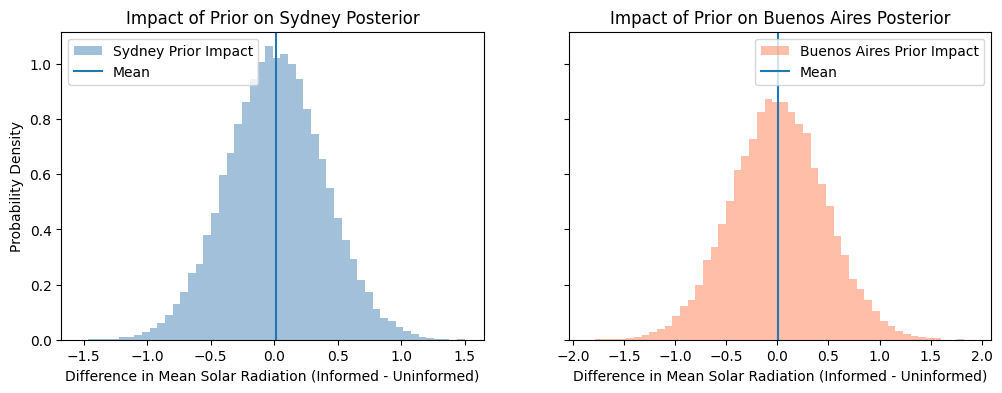

In [ ]:
sydney_prior_impact_mean = np.mean(sydney_prior_impact)
ba_prior_impact_mean = np.mean(ba_prior_impact)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Sydney plot
axes[0].hist(sydney_prior_impact, bins=50, density=True, alpha=0.5, label='Sydney Prior Impact', color='steelblue')
axes[0].set_title('Impact of Prior on Sydney Posterior')
axes[0].set_xlabel('Difference in Mean Solar Radiation (Informed - Uninformed)')
axes[0].set_ylabel('Probability Density')
axes[0].axvline(sydney_prior_impact_mean, linestyle='-', label='Mean')
axes[0].legend()

# Buenos Aires plot
axes[1].hist(ba_prior_impact, bins=50, density=True, alpha=0.5, label='Buenos Aires Prior Impact', color='coral')
axes[1].set_title('Impact of Prior on Buenos Aires Posterior')
axes[1].set_xlabel('Difference in Mean Solar Radiation (Informed - Uninformed)')
axes[1].axvline(ba_prior_impact_mean, linestyle='-', label= 'Mean')
axes[1].legend()
plt.show()

# **FIGURE 4**

# **Learning extension:** What will a wrong informed prior would have on the model

To illustrate what happens when an informed prior is misleading,  a new prior with a mean significantly different from the observed data. We will set the mean to 1.0 kWh/m²/day, which is considerably lower than the actual solar radiation levels in Sydney and Buenos Aires.


<Axes: title={'center': 'mu_wrong_inform_BA'}>

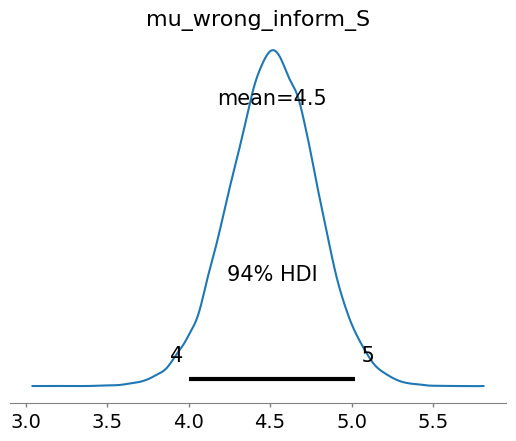

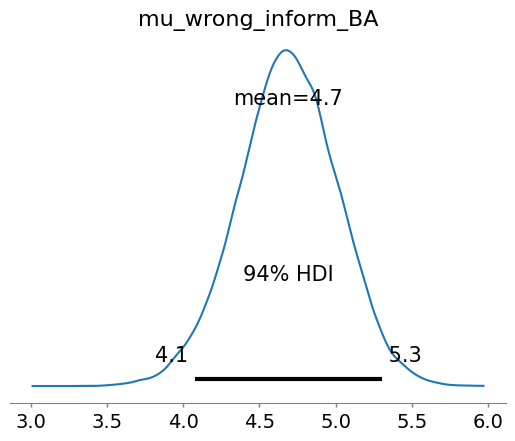

In [ ]:
## Wrongly Informed model SYD

with pm.Model() as wrong_informed_S_model:

    # Prior for the mean - Intentionally wrong prior guess (e.g., too low)
    mu_wrong_inform_S = pm.Normal("mu_wrong_inform_S", mu=1, sigma=1.5)

    # Prior for std of solar radiation — HalfNormal with a standard deviation of 20.
    sigma_wrong_inform_S = pm.HalfNormal("sigma_wrong_inform_S", sigma=2)

    # Likelihood given the data
    obs_S_wrong = pm.Normal("obs_S_wrong", mu=mu_wrong_inform_S, sigma=sigma_wrong_inform_S, observed=df_S["Solar Radiation Level (W/m^2)"])

    # Obtain 20,000 samples from the posterior
    trace_wrong_informed_S = pm.sample(20000, tune=2000, return_inferencedata=True,progressbar=False)

#plot the posterior distribution for the mean
az.plot_posterior(trace_wrong_informed_S, var_names=["mu_wrong_inform_S"])

## Wrongly Informed model Buenos Aires


with pm.Model() as wrong_informed_BA_model:

    # Prior for the mean - Intentionally wrong prior guess (e.g., too low)
    mu_wrong_inform_BA = pm.Normal("mu_wrong_inform_BA", mu=1, sigma=1.5)

    # Prior for std of heights — HalfNormal with a standard deviation of 20.
    sigma_wrong_inform_BA = pm.HalfNormal("sigma_wrong_inform_BA", sigma=2)

    # Likelihood given the data
    obs_BA_wrong = pm.Normal("obs_BA_wrong", mu=mu_wrong_inform_BA, sigma=sigma_wrong_inform_BA, observed=df_BA["Solar Radiation Level (W/m^2)"])

    # Obtain 20,000 samples from the posterior
    trace_wrong_informed_BA = pm.sample(20000, tune=2000, return_inferencedata=True, progressbar=False)

#plot the posterior distribution for the mean
az.plot_posterior(trace_wrong_informed_BA, var_names=["mu_wrong_inform_BA"])

In [ ]:
#extracting the posterior samples for uniformed
mu_samples_uninformed_S = trace_uninformed.posterior['mu_uninformed_S'].values.flatten()
mu_samples_uninformed_BA = trace_uninformed.posterior['mu_uninformed_BA'].values.flatten()

##extracting the posterior samples for informed  samples  as a numpy array
mu_samples_wrong_informed_S = trace_wrong_informed_S.posterior['mu_wrong_inform_S'].values.flatten()
mu_samples_wrong_informed_BA = trace_wrong_informed_BA.posterior['mu_wrong_inform_BA'].values.flatten()

In [ ]:
# posterior distributions of the differences between the non-informative and informative priors
#impact of the prior on Sydney
sydney_wrong_prior_impact = mu_samples_wrong_informed_S - mu_samples_uninformed_S
### Find if zero is within the 95% highest density interval (un-informed)


# impact of the prior on Buenos Aires
ba_wrong_prior_impact =mu_samples_wrong_informed_BA - mu_samples_uninformed_BA

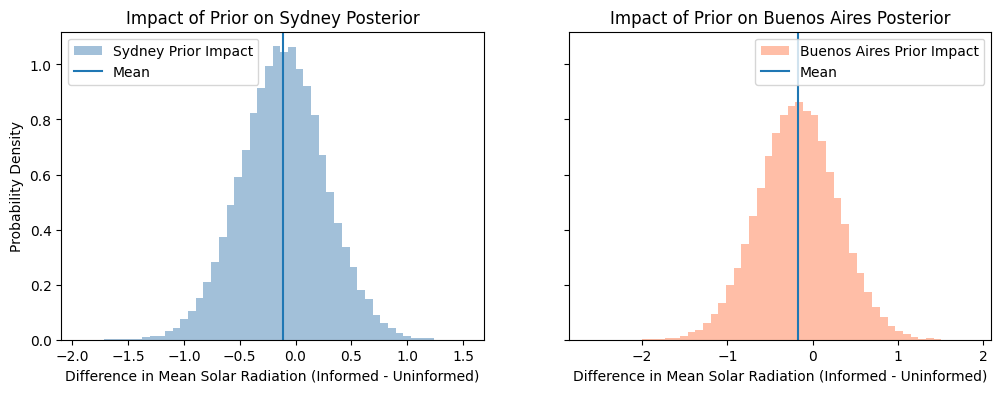

In [ ]:
sydney_wrong_prior_impact_mean = np.mean(sydney_wrong_prior_impact)
ba_wrong_prior_impact_mean = np.mean(ba_wrong_prior_impact)

az.hdi(sydney_wrong_prior_impact, hdi_prob=0.95)
az.hdi(ba_wrong_prior_impact, hdi_prob=0.95)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Sydney plot
axes[0].hist(sydney_wrong_prior_impact, bins=50, density=True, alpha=0.5, label='Sydney Prior Impact', color='steelblue')
axes[0].set_title('Impact of Prior on Sydney Posterior')
axes[0].set_xlabel('Difference in Mean Solar Radiation (Informed - Uninformed)')
axes[0].set_ylabel('Probability Density')
axes[0].axvline(sydney_wrong_prior_impact_mean, linestyle='-', label='Mean')
axes[0].legend()

# Buenos Aires plot
axes[1].hist(ba_wrong_prior_impact, bins=50, density=True, alpha=0.5, label='Buenos Aires Prior Impact', color='coral')
axes[1].set_title('Impact of Prior on Buenos Aires Posterior')
axes[1].set_xlabel('Difference in Mean Solar Radiation (Informed - Uninformed)')
axes[1].axvline(ba_wrong_prior_impact_mean, linestyle='-', label='Mean')
axes[1].legend()
plt.show()

# **Figure 5**

# Interpretation - Clover

###Model Interpretation

Both uninformed and informed Baysian models were used to estimate the posterior distribution of the solar radiation for Sydney and Buenos Aires. The uninformed model uses flat priors which allow the data to dominate the posterior, while the informed model incorporates NASA latitude solar radiation scaling to define the prior mean and standard deviation.

Both models produce similar posterior means, Sydney at 4.6 kWh/m^2/day and Buenos Aires at 4.9 kWh/m^2/day (see **Fig 1** showing this similarity between the models). Hence regardless of an informative or non-informative approach the data sufficiently dominated the posterior, this improves our confidence in the result and validates our prior selection. If the informed and uninformed results diverged significantly it would have suggested the prior was inconsistent with the data.

###City Comparison

The posterior means of the two cities differ slightly:
- Sydney 4.6 kWh/m^2/day
- Buenos Aires 4.9 kWh/m^2/day

However to determine if this difference is statistically credible we must assess the 95% credible interval on the difference of the means.
- Uninformed: -1.09 to 0.59
- Informed: -1.07 to 0.58

In both models zero is contained within the interval (see **Fig 3** for visualisation), hence a true difference of 0 cannot be ruled out. This is consistent with our hypothesis that two cities at similar latitudes should receive comparable solar radiation.

- For both Sydney and Buenos Aires, the 95% HDI for the difference between the informed and uninformed posterior means contains zero (**See Fig 4**). This indicates that, for the given dataset and selected informed priors, there is no statistical difference between the posterior distributions when using informative priors versus when using non-informative or flat priors.



## Physical Interpretation

It is evident Buenos Aires has a marginally higher mean radiation (by direct comparison of the posterior means, see **Fig 2**), this is physically plausible. There are several confounding factors that can contribute to differences between the cities despite being located at similar latitudes:
- cloud cover and ocean currents: Sydney is on the eastern coast of Australia and is influenced by the East Australian Current (EAC) while Buenos Aires is in proximity to the Rio de la Plata Estuary. This could result in somewhat clearer skies in Buenos Aires (ie. the EAC carries warm water along the Australian coast, increasing rainfall while Buenos Aires has a more protected continental climate)
- population and urbanisation: greater population density will lead to increased aerosol and particulate pollution which scatters/reflects incoming solar radiation before reaching the surface. Hence this could affect the solar radiation levels at each city.
- minor latitude variation: both cities are located near 34°S, however they differ by 0.7°. This can cause slightly different solar geometry across the seasons, producing systematic differences in monthly means.

- For both Sydney and Buenos Aires, the 95% HDI for the difference between the informed and uninformed posterior means was extremely close to zero. This indicates that the informed prior had almost no tendency to shift the posterior mean away from what the uninformed prior produced.


### Physical Interpretation: learning experiment

To better understand how a misinformed prior would impact this dataset, we decided to do a simple learning experiment. We set the mean (Mu) of the prior to an unrealistic solar radiation value of 1.0 kWh/m²/day. Performing the same analysis as with the informed versus uninformed comparison, we did observe a difference. The mean of the 95% HDI shifted slightly, indicating the misinformed prior did indeed influence the model, though the shift was very minimal. Additionally, there was an increase in the 95% Credible Interval (or HDI) observed in Fig 5 when compared to Fig 4. A wider HDI for the difference means there's a broader range of plausible values for how much the misinformed prior impacted the posterior, reflecting increased uncertainty due to the conflict between the prior and the data.

## Limitations
The dataset used spans only 3 years (2022-2024) which is a relatively short timeframe to draw strong conclusions. Additionally interannual variability caused by ENSO cycles may disproportionally affect one city over that time period. A longer time series would reduce this uncertainty.

Additionally a stronger analysis could be undertaken to compare if solar radiation levels have changed over time between the two cities. This could provide insight into how development, population and climate changes affect recorded solar radiation levels and if these factors differ between the two cities.    


# Individual Reflections

### Data Steward - Ellie

My role as data steward was not super hard, but was very important and required to be done quickly in order for my group members to start their roles. I had originally been uncertain as to what the exact question and hypothesis would be due to unclear comunication in our planning session on Friday, however I quickly resolved thisthrough further chats with group members and a little research. Another problem I ran into was which parmaeters to use in the NASA website (e.g. irradiance vs radiance, all sky vs clear sky) but I resolved this quickly with research. Whilst there were a couple of minor setbacks, I feel as though I completed my role in a timely manner and to a good extent.

### Analysis and Modelling - Justin

One of the more challenging parts of the analysis was effectively selecting and constructing an informative prior, which felt unnatural coming from a background of purely frequentist analysis/methods, where this kind of prior knowledge is never explicitly required. Unlike the uninformed case where a flat prior is simply assumed, the informed model required me to research and critically think about the quality of the sources I used and possibly how different sources may impact the final results. Before selecting the prior I questioned what actually constitutes a prior, the best method for obtaining a well-informed value, and how confident I was in the estimate. Initially, I attempted to identify areas of similar latitude, but it became clear this alone was insufficient as it was difficult to assign an uncertainty I was comfortable with. During research it became evident that within different latitude bands a scaling factor could be applied to better estimate expected solar radiation, which helped ground both the prior value and my confidence in the uncertainty.



### Visualisation and Interpretation - Clover

This week I worked on the visualisation and interpretation role. We had some difficulty defining our problem this week, as such the data that ended up being modelled produced mean solar radiation levels for each city instead of the change in solar radiation across 20 years. This required me to change approach for my interpretation: focusing on how the uninformed and informed models could be compared and what the credible interval can tell us about the difference between the city mean radiation. To support my interpretation I decided it was important to plot the posterior distributions of each city together (to compare the means directly) and plot the posterior distributions of both models together (to compare the effect of informed priors and discuss the role of the data in driving the model). All in all, though the content was somewhat more challenging this week, the process of interpreting the model helped me contextualise and understand how it can be applied.

### Github and Integration - Owen
My role this week was the project Github and integration management. As such, my job was to ensure the creation of a structured and clear initial document, so that my team members could easily perform their respective roles. With this, there was a clear flow and order in which the tasks needed to be completed; and the project completion followed this flow. Additionally, I was the one posting the announcement (of which contained the project link) in the canvas group. This was fairly straightforward, and even more so with the guidance of last week's Github and Integration manager: Clover, who gave me tips for areas I was unsure of at times. I also kept track of project progress, updating team members about areas that needed completion, and reminding them to complete their reflections before I made the final commit to Github.

Alongside this, I found myself also making sure the correct files were integrated, and that they worked for all group memebers so that everyone could understand the steps we each took. Sepcifically, the initial data set was integrated through a google sheets link, which when tested, only worked for a few of our memebrs rather than all. This was quickly fixed by converting the data into a .xlsx document, with the relevant code also fixed accordingly to accommodate this change.

### Narrative - Freddie

As the narrative lead this week, my role was to write the markdown explanation in the notebook, ensure logical flow from question and to summarise key decisions and limitations. As one of the later roles in the project, my work wasn't incredibly difficult. My amazing team set everything up perfectly, there was little work that I had to do apart from editing some captions here and there. I changed some of the information so that it flowed more logically and was more easily understandable to someone who hasn't seen our project or code before. I had to really read through our project very closely to spot the areas which needed changing. Overall, my work was more on the back end, tightening things up, cleaning code and adding some descriptions.

### Quality Control and Reproducibility - Ed

 After visiting each section, I understand that the hypothesis tested was positively supported by the data observed. The project has a high degree of reproducibility as any researcher can use the same data, however due to a variety of confounding factors the data is at risk of producing generalisations depending on how it is interpreted. Confounding factors and limitations in the data observed are clearly defined and are important contributions to the project. In trying to assess 'quality control'; I see relevance throughout all cells/sections provided and a 'logical flow' as described in the Narrative summary.

I also feel it is important that I mention that I was intitially tasked with Visualisation and Interpretaiton, however I did not complete my role and was kindly supported by other members in the team (particularly Clover) who did the entire section in place of me. Undertaking the role of Quality Control and Reproducibility has had no impact on the project itself. My lack of familiarity with Bayes Theorem hinders my ability to process the methodology of the project.